# Malins notebook för att testa

**Dataset:** Quality Prediction in a Mining Process  
https://www.kaggle.com/datasets/edumagalhaes/quality-prediction-in-a-mining-process/data  
Se README för nedladdning.



In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/MiningProcess_Flotation_Plant_Database.csv", decimal=",")
df["date"] = pd.to_datetime(df["date"])

print(df.shape)
print(df.head(5))
df.info()

(737453, 24)
                 date  % Iron Feed  % Silica Feed  Starch Flow  Amina Flow  \
0 2017-03-10 01:00:00         55.2          16.98      3019.53     557.434   
1 2017-03-10 01:00:00         55.2          16.98      3024.41     563.965   
2 2017-03-10 01:00:00         55.2          16.98      3043.46     568.054   
3 2017-03-10 01:00:00         55.2          16.98      3047.36     568.665   
4 2017-03-10 01:00:00         55.2          16.98      3033.69     558.167   

   Ore Pulp Flow  Ore Pulp pH  Ore Pulp Density  Flotation Column 01 Air Flow  \
0        395.713      10.0664              1.74                       249.214   
1        397.383      10.0672              1.74                       249.719   
2        399.668      10.0680              1.74                       249.741   
3        397.939      10.0689              1.74                       249.917   
4        400.254      10.0697              1.74                       250.203   

   Flotation Column 02 Air Flow

In [2]:
start = df["date"].min()
end = df["date"].max()

print(f"Startdatum: {start}")
print(f"Slutdatum:  {end}")
print(f"Tidsperiod: {(end - start).days} dagar")

Startdatum: 2017-03-10 01:00:00
Slutdatum:  2017-09-09 23:00:00
Tidsperiod: 183 dagar


Datasetet innehåller 737 453 rader och 24 kolumner och löper över 183 dagar från 2017-03-10 till 2017-09-09.

In [3]:
# Antal unika timmar och rader per timme
per_hour = df.groupby("date").size()
print("Unika timmar:", per_hour.shape[0])
print(per_hour.describe())

Unika timmar: 4097
count    4097.000000
mean      179.998291
std         0.095028
min       174.000000
25%       180.000000
50%       180.000000
75%       180.000000
max       180.000000
dtype: float64


Det finns 4 097 unika timmar med nästan exakt 180 rader var (20-sekundersdata).  
4 097 × 180 = 737 460, och det finns 737 453 rader, så bara någon enstaka timme är ofullständig. 

In [4]:
# Helt identiska rader
print("Identiska rader:", df.duplicated().sum())

Identiska rader: 1171


In [5]:
# Var finns de identiska raderna?
duplicate_rows = df[df.duplicated(keep=False)]
print(duplicate_rows.groupby("date").size())

date
2017-03-12 01:00:00      2
2017-06-01 15:00:00      6
2017-06-28 15:00:00     15
2017-06-28 16:00:00     85
2017-06-29 14:00:00     11
2017-06-29 15:00:00     17
2017-07-11 06:00:00     82
2017-07-11 07:00:00    180
2017-07-11 08:00:00    180
2017-07-11 09:00:00    180
2017-07-11 10:00:00     47
2017-07-13 14:00:00    123
2017-07-13 15:00:00    180
2017-07-13 16:00:00     40
2017-07-26 11:00:00     38
dtype: int64


   Det finns 1 171 identiska rader, och de är samlade i några få perioder.  
   Den 11 juli kl. 07–09 och den 13 juli kl. 15 är hela timmar fastfrusna (180 av 180 rader identiska).  
   Det är osannolikt att en fungerande process ger exakt samma värden i alla sensorer under flera timmar.  
   Ett antagande är att en mätare fastnat eller att systemet loggat samma värden under ett stopp. 

In [6]:
# Luckor: timmar som saknas mellan första och sista tidpunkt
all_hours = pd.date_range(df["date"].min(), df["date"].max(), freq="h")
missing = all_hours.difference(per_hour.index)
print("Saknade timmar:", len(missing))
print(missing[:10])

Saknade timmar: 318
DatetimeIndex(['2017-03-16 06:00:00', '2017-03-16 07:00:00',
               '2017-03-16 08:00:00', '2017-03-16 09:00:00',
               '2017-03-16 10:00:00', '2017-03-16 11:00:00',
               '2017-03-16 12:00:00', '2017-03-16 13:00:00',
               '2017-03-16 14:00:00', '2017-03-16 15:00:00'],
              dtype='datetime64[us]', freq='h')


In [7]:
# Är luckan på 318 timmar sammanhängande?
gaps = missing.to_series().diff() != pd.Timedelta("1h")
print(missing.to_series().groupby(gaps.cumsum()).agg(["min", "max", "count"]))

                  min                 max  count
1 2017-03-16 06:00:00 2017-03-29 11:00:00    318


Luckan på 318 timmar är ett sammanhängande stopp mellan 2017-03-16 och 2017-03-29, kanske ett driftstopp.  
**Förslag:** Data fram till 2017-03-29 används inte utan rensas bort. Den sammanhängande datan mellan 2017-03-29 kl. 12 till 2017-09-09 används.

count    4097.000000
mean        2.328527
std         1.130737
min         0.600000
25%         1.440000
50%         2.000000
75%         3.010000
max         5.530000
Name: % Silica Concentrate, dtype: float64


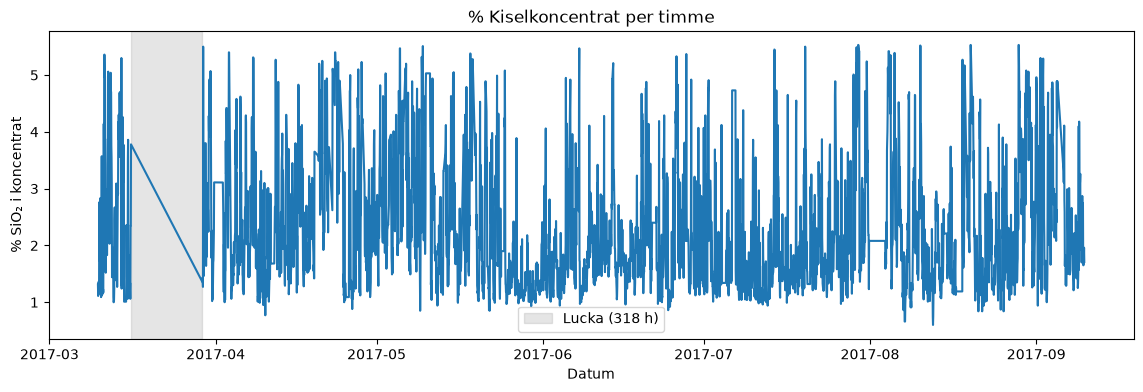

In [8]:
# Målvariabeln på timnivå, plottad över tid
hourly_target = df.groupby("date")["% Silica Concentrate"].first()
print(hourly_target.describe())

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 4))
plt.plot(hourly_target.index, hourly_target.values)
plt.title("% Kiselkoncentrat per timme")
plt.xlabel("Datum")
plt.ylabel("% SiO₂ i koncentrat")
plt.axvspan(missing.min(), missing.max(), color="gray", alpha=0.2, label="Lucka (318 h)")
plt.legend()
plt.show()

   Det grå fältet markerar luckan på 318 timmar (16–29 mars). Det diagonala strecket inom fältet är inte data, utan linjen dras mellan sista och första mätningen runt luckan.  
   De horisontella strecken är perioder där kiselhalten är exakt oförändrad i många timmar, medan övriga sensorvärden fortsätter att variera.  
   Det tyder på att labbvärdet upprepats snarare än mätts på nytt, se tabellen nedan.

In [9]:
# Hitta sammanhängande perioder där målvärdet inte ändras
changed = hourly_target.diff() != 0
run_id = changed.cumsum()
runs = hourly_target.groupby(run_id).agg(
    start=lambda s: s.index.min(),
    end=lambda s: s.index.max(),
    value="first",
    hours="size",
)
print(runs[runs["hours"] >= 6].sort_values("hours", ascending=False))

                                   start                 end  value  hours
% Silica Concentrate                                                      
2821                 2017-07-31 20:00:00 2017-08-03 20:00:00   2.08     73
181                  2017-03-31 17:00:00 2017-04-02 07:00:00   3.11     39
3117                 2017-08-17 02:00:00 2017-08-18 05:00:00   1.19     28
1039                 2017-05-10 05:00:00 2017-05-10 23:00:00   5.03     19
1978                 2017-06-21 09:00:00 2017-06-22 03:00:00   2.40     19
2240                 2017-07-04 11:00:00 2017-07-05 03:00:00   1.34     17
2264                 2017-07-06 07:00:00 2017-07-06 22:00:00   4.73     16
389                  2017-04-11 06:00:00 2017-04-11 21:00:00   1.68     16
698                  2017-04-25 06:00:00 2017-04-25 20:00:00   1.09     15
1350                 2017-05-24 06:00:00 2017-05-24 19:00:00   1.90     14
2573                 2017-07-20 08:00:00 2017-07-20 20:00:00   1.32     13
3076                 2017

   Det finns 19 perioder på minst 6 timmar där kiselhalten är exakt oförändrad, sammanlagt cirka 330 timmar (ungefär 8 % av datan).  
   Den längsta är 73 timmar (31 juli – 3 augusti).  
   Perioden 14–15 mars ligger före luckan och försvinner om förslaget att börja 29 mars godtas.

   ## Öppna frågor
   - Ska datan före luckan (10–16 mars) tas bort?
   - Hur ska fastfrusna timmar och perioder med konstant kiselhalt hanteras?
   - `% Iron Concentrate` mäts samtidigt som målet och bör inte användas som indata (dataläckage).
   - Vilken prognoshorisont är intressant för användaren?